# Mechanistic models

EpiLearn 0.1.0 has three separate mechanistic layers, and it matters which one you reach for:

| what you want | what to use |
|---|---|
| a torch simulator that rolls a compartmental recursion forward | `epilearn.models.Temporal.Compartmental` -- `SIR`, `SIS`, `SEIR` (and the `Network*` variants), plus `epilearn.models.SpatialTemporal.NetSIR` |
| a configurable ODE system with RK4 integration, time-varying parameters, individual- and region-level spread | `epilearn.utils.compartmental_models` + `epilearn.utils.simulation` |
| a compartmental model used as a **forecaster**, scored next to GRU/DLinear/... | `epilearn.models.Temporal.SIRModel` / `SISModel` / `SEIRModel` |

The last row is the one that trips people up: `SIR`, `SIS` and `SEIR` are `nn.Module` simulators with
a `forward(x, steps)` signature -- they have no `fit`/`predict`, so they **cannot** be passed as
`prototype=` to a task. The `...Model` classes in `epilearn.models.Temporal` can: their `fit` is a
no-op and `predict` fits the ODE parameters per lookback window.

`epilearn.models.Temporal.SIR` still imports as a deprecated alias of
`epilearn.models.Temporal.Compartmental`.

In [1]:
import os
import sys

# Run from the repository root so that "./datasets" (and "./examples") resolve,
# no matter whether this notebook was launched from examples/ or from the root.
if os.path.basename(os.getcwd()) == "examples":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [2]:
import torch
import matplotlib.pyplot as plt

from epilearn.models.Temporal.Compartmental import SIR, SIS, SEIR
from epilearn.models.SpatialTemporal import NetSIR
from epilearn.utils import simulation
from epilearn import visualize

torch.manual_seed(7)
device = 'cpu'

/home/ec2-user/miniconda3/envs/epilearn/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. The torch simulators

`SIR(horizon=..., infection_rate=..., recovery_rate=...)` takes a length-3 initial state
`[S, I, R]` (counts) and returns a `(horizon, 3)` trajectory.

initial state: tensor([3416.,  210.,   65.])
trajectory: (100, 3)


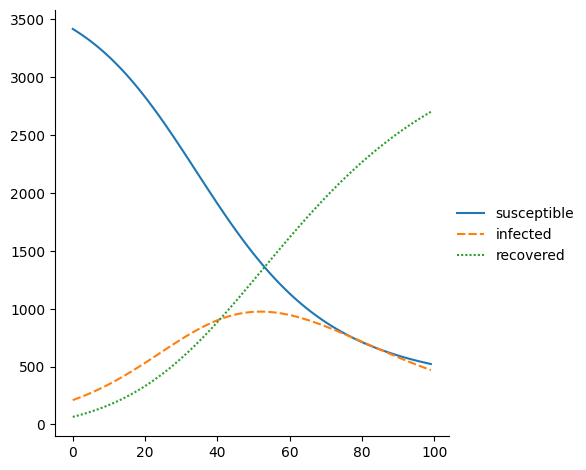

In [3]:
data = torch.tensor([3416.0, 210.0, 65.0])   # [S, I, R]
print("initial state:", data)

model = SIR(horizon=100, infection_rate=0.1, recovery_rate=0.0384)
preds = model(data, steps=None)               # steps=None -> use horizon
print("trajectory:", tuple(preds.shape))

visualize.plot_series(preds.detach().numpy(),
                     columns=['susceptible', 'infected', 'recovered'])

`SIS` and `SEIR` follow the same pattern; only the length of the state vector changes
(`[S, I]` and `[S, E, I, R]`).

In [4]:
sis = SIS(horizon=100, infection_rate=0.1, recovery_rate=0.04)
seir = SEIR(horizon=100, infection_rate=0.1, recovery_rate=0.04, latency=0.2)

print("SIS :", tuple(sis(torch.tensor([3416.0, 210.0]), steps=None).shape))
print("SEIR:", tuple(seir(torch.tensor([3416.0, 120.0, 210.0, 65.0]), steps=None).shape))

SIS : (100, 2)
SEIR: (100, 4)


## 2. Spreading on a contact network

`NetSIR` runs the same recursion per node, coupled through an adjacency matrix.

trajectory (steps, nodes, compartments): (120, 15, 3)


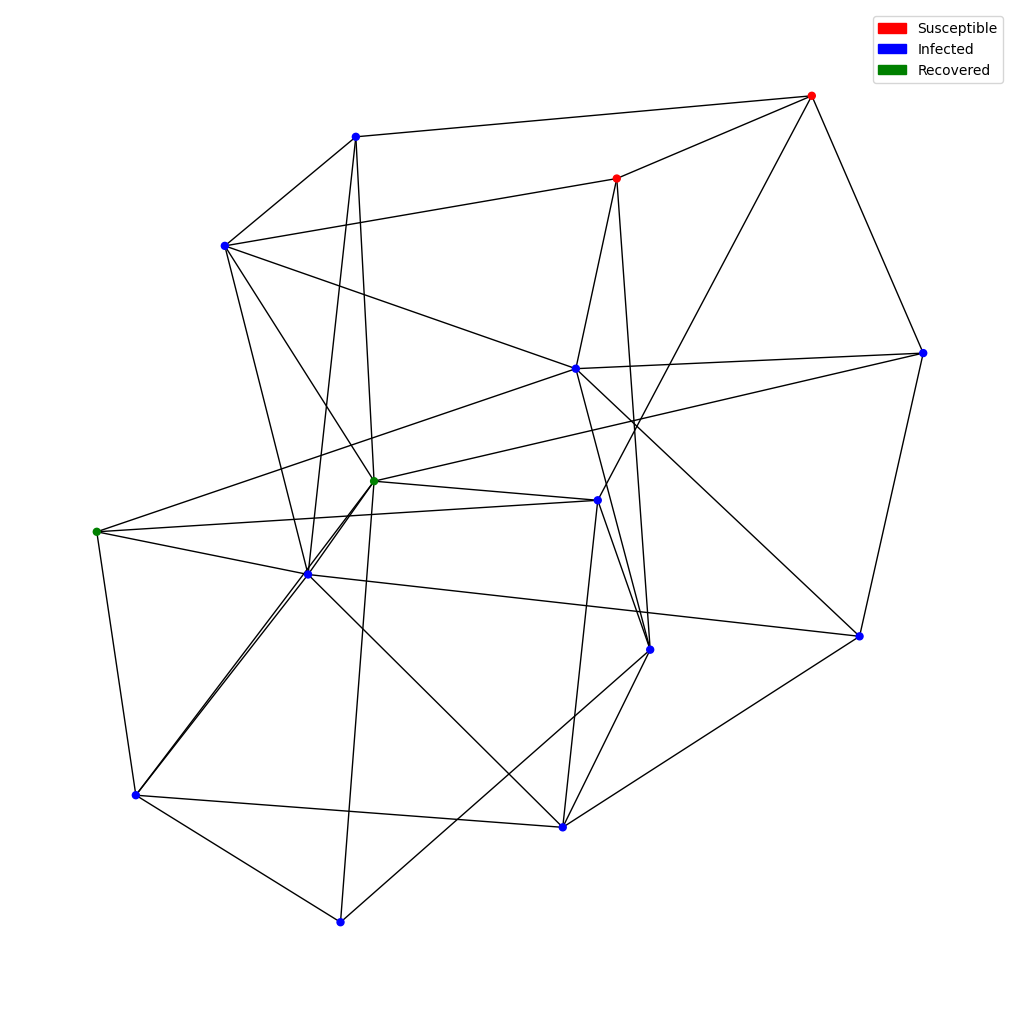

In [5]:
initial_graph = simulation.get_random_graph(num_nodes=15, connect_prob=0.4)

initial_states = torch.zeros(15, 3)   # [S, I, R] one-hot per node
initial_states[:, 0] = 1
for node in (3, 4):                   # seed two infected individuals
    initial_states[node, 0] = 0
    initial_states[node, 1] = 1

net = NetSIR(num_nodes=initial_graph.shape[0], horizon=120,
             infection_rate=0.05, recovery_rate=0.05)
net_preds = net(initial_states, initial_graph, steps=None)
print("trajectory (steps, nodes, compartments):", tuple(net_preds.shape))

layout = visualize.plot_graph(net_preds.argmax(2)[15].detach().numpy(),
                             initial_graph.to_sparse().indices().detach().numpy(),
                             classes=['Susceptible', 'Infected', 'Recovered'])

## 3. `epilearn.utils.compartmental_models`: ODE systems with time-varying parameters

`SIRModel`, `SEIRModel`, `SIRSModel` and `SEIRVIModel` here are declarative ODE systems (fractions,
not counts). `simulate_temporal_epidemic` integrates them (RK4 by default) and accepts a
`parameter_schedule`, which is how you express an intervention.

A schedule can be a dict (`{step: overrides}`, applied at that single step) or a callable
`f(step_idx, t, state) -> overrides or None`, which is what you want for a sustained intervention.

compartments: ('S', 'I', 'R')
parameters  : {'beta': 0.35, 'gamma': 0.1, 'mu': 0.0, 'birth_rate': 0.0}



peak prevalence  no NPI: 0.359   with NPI: 0.101
final attack rate no NPI: 0.966   with NPI: 0.876


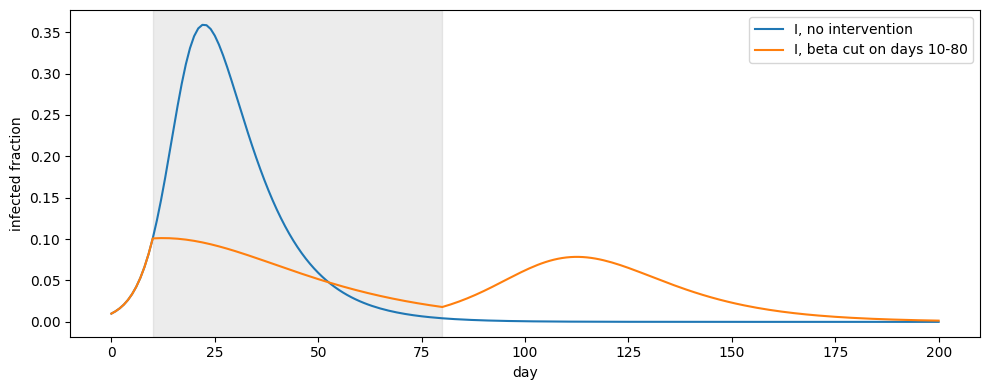

In [6]:
from epilearn.utils.compartmental_models import SIRModel, SEIRModel, SIRSModel, SEIRVIModel
from epilearn.utils.simulation import simulate_temporal_epidemic

sir = SIRModel(beta=0.35, gamma=0.1)
print("compartments:", sir.compartments)
print("parameters  :", sir.parameters)

free = simulate_temporal_epidemic(sir, initial_state=[0.99, 0.01, 0.0], steps=200)


def npi(step_idx, t, state):
    """Cut transmission between day 10 and day 80."""
    return {'beta': 0.12} if 10 <= step_idx < 80 else None


damped = simulate_temporal_epidemic(sir, initial_state=[0.99, 0.01, 0.0], steps=200,
                                   parameter_schedule=npi)

print(f"\npeak prevalence  no NPI: {float(free['trajectory'][:, 1].max()):.3f}"
      f"   with NPI: {float(damped['trajectory'][:, 1].max()):.3f}")
print(f"final attack rate no NPI: {float(1 - free['trajectory'][-1, 0]):.3f}"
      f"   with NPI: {float(1 - damped['trajectory'][-1, 0]):.3f}")

plt.figure(figsize=(10, 4))
plt.plot(free['time'], free['trajectory'][:, 1], label='I, no intervention')
plt.plot(damped['time'], damped['trajectory'][:, 1], label='I, beta cut on days 10-80')
plt.axvspan(10, 80, color='grey', alpha=0.15)
plt.xlabel('day')
plt.ylabel('infected fraction')
plt.legend()
plt.tight_layout()
plt.show()

`SEIRModel` / `SIRSModel` / `SEIRVIModel` only differ in their compartment list, and every model also
exposes `simulate()` directly.

In [7]:
for model in [SIRModel(beta=0.4, gamma=0.1),
              SEIRModel(beta=0.4, gamma=0.1, sigma=0.2),
              SIRSModel(beta=0.4, gamma=0.1, omega=0.02),
              SEIRVIModel(beta=0.4, gamma=0.1, sigma=0.2)]:
    state = [0.99] + [0.0] * (len(model.compartments) - 2) + [0.01]
    state = state[:len(model.compartments)]
    state[0] = 1.0 - sum(state[1:])
    out = model.simulate(state, steps=50)
    print(f"{type(model).__name__:14s} {str(model.compartments):40s} -> {tuple(out['trajectory'].shape)}")

SIRModel       ('S', 'I', 'R')                          -> (51, 3)
SEIRModel      ('S', 'E', 'I', 'R')                     -> (51, 4)
SIRSModel      ('S', 'I', 'R')                          -> (51, 3)
SEIRVIModel    ('S', 'E', 'I', 'R', 'V', 'Q')           -> (51, 6)


The same models drive the individual- and region-level simulators. `Time_geo` was removed in 0.1.0;
these three functions replace it.

individual  counts: (61, 3) node_features: (61, 60, 3)


region      trajectory: (121, 25, 3) counts: (121, 3)


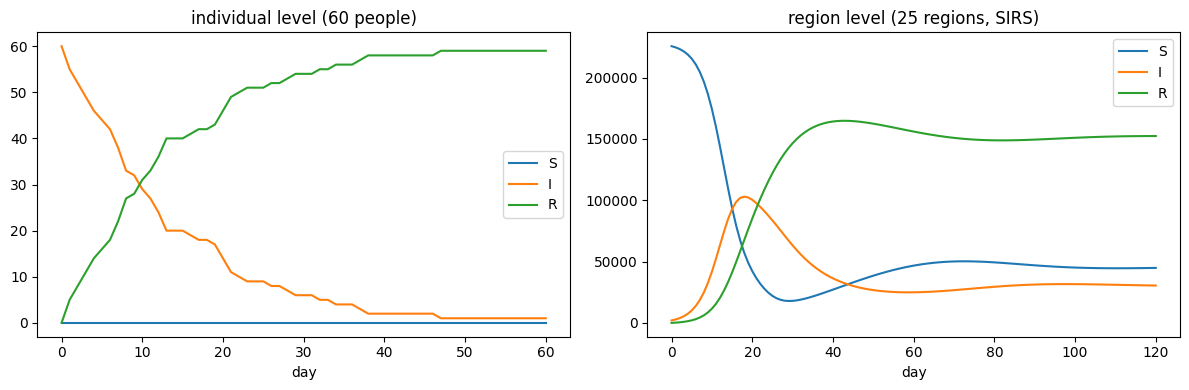

In [8]:
from epilearn.utils.simulation import (create_initial_conditions_individual,
                                     create_initial_conditions_region,
                                     simulate_spatiotemporal_individual,
                                     simulate_spatiotemporal_regions)

# --- individual level: one node per person, spread over a contact graph ---
node_states, contact_graph = create_initial_conditions_individual(
    SIRModel(beta=0.35, gamma=0.1), num_individuals=60, p_edge=0.08,
    initial_compartment_fractions={'I': 0.05}, seed=1)

individual = simulate_spatiotemporal_individual(
    SIRModel(beta=0.35, gamma=0.1), contact_graph, node_states, steps=60, seed=1)
print("individual  counts:", tuple(individual['counts'].shape),
      "node_features:", tuple(individual['node_features'].shape))

# --- region level: population counts per region, coupled by mobility ---
region_init = create_initial_conditions_region(
    SIRSModel(beta=0.5, gamma=0.1, omega=0.02), n_regions=25, p_edge=0.15, seed=3)

regions = simulate_spatiotemporal_regions(
    SIRSModel(beta=0.5, gamma=0.1, omega=0.02),
    region_init['region_states'],
    region_init['adjacency'] / region_init['adjacency'].max(),
    steps=120, travel_rate=0.05)
print("region      trajectory:", tuple(regions['trajectory'].shape),
      "counts:", tuple(regions['counts'].shape))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for i, name in enumerate(individual['compartments']):
    axes[0].plot(individual['counts'][:, i], label=name)
axes[0].set_title('individual level (60 people)')
axes[0].set_xlabel('day')
axes[0].legend()
for i, name in enumerate(regions['compartments']):
    axes[1].plot(regions['counts'][:, i], label=name)
axes[1].set_title('region level (25 regions, SIRS)')
axes[1].set_xlabel('day')
axes[1].legend()
plt.tight_layout()
plt.show()

## 4. A compartmental model as a forecaster

`epilearn.models.Temporal.SIRModel` / `SISModel` / `SEIRModel` wrap the ODE in the standard model
interface: `fit` is a no-op and `predict` re-fits `(beta, gamma, ...)` to every lookback window with
L-BFGS-B, then integrates forward over the horizon. That makes them usable as `prototype=` and
directly comparable with the learned models.

In [9]:
from epilearn.data import Dataset
from epilearn.tasks.forecast import Forecast
from epilearn.models.Temporal import SIRModel as SIRForecaster
from epilearn.models.Temporal import SEIRModel as SEIRForecaster
from epilearn.models.Temporal import SeasonalNaiveModel

toy = Dataset()
toy.load_toy_dataset()
series = toy.y[:, 0].unsqueeze(-1)            # one region, (time, 1)
dataset = Dataset(x=series, y=series)

for name, prototype in [('SIRModel', SIRForecaster),
                        ('SEIRModel', SEIRForecaster),
                        ('SeasonalNaiveModel', SeasonalNaiveModel)]:
    task = Forecast(prototype=prototype, dataset=None, lookback=21, horizon=7, device=device)
    result = task.rolling_train(dataset=dataset,
                               train_size=300, val_size=60, test_size=60,
                               train_loss='mse', epochs=1, batch_size=8,
                               max_folds=2)
    metrics = result['aggregate_metrics']
    print(f"\n>>> {name:20s} MAE {metrics['mae_mean']:8.3f}   RMSE {metrics['rmse_mean']:8.3f}")


Rolling Evaluation Setup


Train: 300, Val: 60, Test: 60, Step: 60



--- Fold 1 ---


Train: 300 [0 - 299]


Val:   60 [300 - 359]


...

  Quantile: 246.8096 ± 189.3334


  Coverage: 55.6% ± 43.1%


  Interval Width: 493.6192 ± 378.6668



Total time: 0.01s, Memory: +0.00 MB



>>> SeasonalNaiveModel   MAE  174.552   RMSE  217.467


Because `SIR`, `SIS` and `SEIR` have no `fit`/`predict`, passing one of them as `prototype=` fails --
use the `...Model` classes above instead.

In [10]:
task = Forecast(prototype=SIR, dataset=None, lookback=21, horizon=7, device=device)
try:
    task.rolling_train(dataset=dataset, train_size=300, val_size=60, test_size=60,
                       epochs=1, batch_size=8, max_folds=1)
except Exception as error:
    print(f"as expected: {type(error).__name__}: {error}")


Rolling Evaluation Setup


Train: 300, Val: 60, Test: 60, Step: 60



--- Fold 1 ---


Train: 300 [0 - 299]


Val:   60 [300 - 359]


Test:  60 [360 - 419]


as expected: TypeError: SIR.__init__() got an unexpected keyword argument 'num_features'
